In [48]:
# This model predicts fire risk severity, based on longitude and latitude input
import pandas as pd

df = pd.read_csv('National_USFS_Fire.csv', low_memory=False) # dataframe

# Remove irrelevant data from dataset
columns_to_keep = ['LATDD83', 'LONGDD83', 'FIREYEAR', 'TOTALACRES', 'STATCAUSE', 'DISCOVERYDATETIME', 'FIRETYPECATEGORY', 'FIREOUTDATETIME'] 

df = df[columns_to_keep]

In [49]:
# Convert datetimes into months and Day_of_Years
df['DISCOVERYDATETIME'] = pd.to_datetime(df['DISCOVERYDATETIME'], errors='coerce')
df['MONTH'] = df['DISCOVERYDATETIME'].dt.month
df['DAY_OF_YEAR'] = df['DISCOVERYDATETIME'].dt.dayofyear

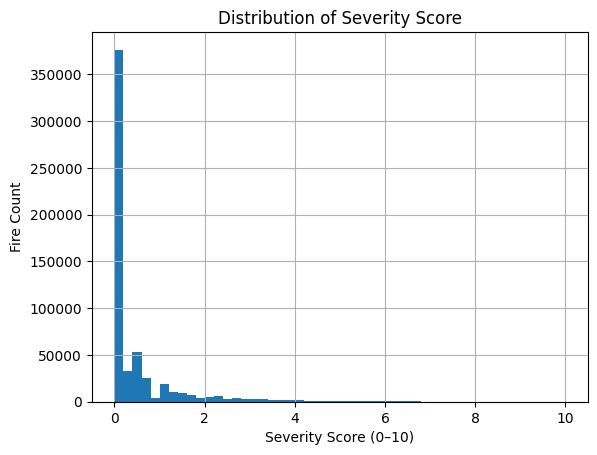

In [50]:
import numpy as np

# Avoid log(0) by adding 1
df['TOTALACRES'] = df['TOTALACRES'].fillna(0)
log_acres = np.log1p(df['TOTALACRES'])  # log(1 + x)

# Normalize to 0–10
log_acres_norm = (log_acres - log_acres.min()) / (log_acres.max() - log_acres.min())
df['severity_score'] = log_acres_norm * 10

import matplotlib.pyplot as plt
df['severity_score'].hist(bins=50)
plt.title("Distribution of Severity Score")
plt.xlabel("Severity Score (0–10)")
plt.ylabel("Fire Count")
plt.show()

Columns in df_clean: ['LATDD83', 'LONGDD83', 'MONTH', 'DAY_OF_YEAR', 'severity_score']
Shape after cleaning: (531954, 5)

Feature ranges:
LATDD83: -117.23 to 438897.00
LONGDD83: -1038467.00 to 1011212.77
MONTH: 0.00 to 1.00
DAY_OF_YEAR: 0.00 to 1.00
severity_score: 0.00 to 10.00
Fitting 3 folds for each of 1 candidates, totalling 3 fits

Best XGBoost parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.8}

KMeans Clustering Performance Metrics:
R^2 Score: 0.1115
RMSE: 0.8999

XGBoost Performance Metrics:
R^2 Score: 0.1278
RMSE: 0.8916

Ensemble Performance Metrics:
R^2 Score: 0.1279
RMSE: 0.8915


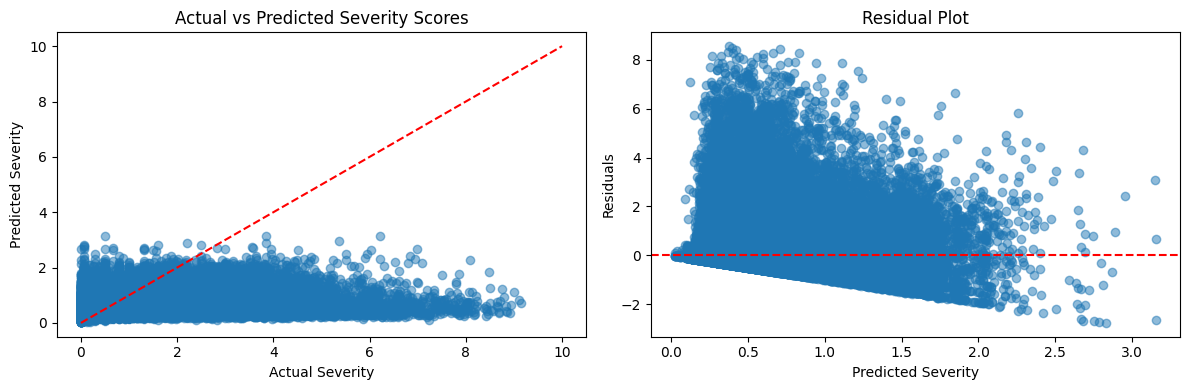


Example prediction for Portland, OR in July:
Predicted fire risk severity: 0.08


In [61]:
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# First ensure temporal features exist
df['MONTH'] = pd.to_datetime(df['DISCOVERYDATETIME'], errors='coerce').dt.month
df['DAY_OF_YEAR'] = pd.to_datetime(df['DISCOVERYDATETIME'], errors='coerce').dt.dayofyear

# Clean data and create features with verified columns
df_clean = df[['LATDD83', 'LONGDD83', 'MONTH', 'DAY_OF_YEAR', 'severity_score']].copy()

# Handle missing values
df_clean = df_clean.dropna()

# Verify columns before scaling
print("Columns in df_clean:", df_clean.columns.tolist())

# Scale temporal features to match spatial scale
df_clean['MONTH'] = (df_clean['MONTH'] - 1) / 11  # Scale to 0-1
df_clean['DAY_OF_YEAR'] = (df_clean['DAY_OF_YEAR'] - 1) / 365  # Scale to 0-1


# Verify data cleaning
print("Shape after cleaning:", df_clean.shape)
print("\nFeature ranges:")
for col in df_clean.columns:
    print(f"{col}: {df_clean[col].min():.2f} to {df_clean[col].max():.2f}")

# Split data
X = df_clean[['LATDD83', 'LONGDD83', 'MONTH', 'DAY_OF_YEAR']]
y = df_clean['severity_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.model_selection import GridSearchCV

# 1. XGBoost parameter grid
xgb_param_grid = {
    'n_estimators': [1000],  
    'max_depth': [5],    
    'learning_rate': [0.05],  
    'min_child_weight': [1],   
    'subsample': [0.8],    
    'colsample_bytree': [0.8]    
}
# Perform Grid Search for XGBoost
xgb_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)

# Use best models for prediction
xgb_model = xgb_grid.best_estimator_

print("\nBest XGBoost parameters:", xgb_grid.best_params_)

# 1. KMeans Clustering Model
k = 1000
kmeans = KMeans(n_clusters=k, random_state=42)
train_clusters = kmeans.fit_predict(X_train[['LATDD83', 'LONGDD83']])

train_df = X_train[['LATDD83', 'LONGDD83']].copy()
train_df['cluster'] = train_clusters
train_df['severity_score'] = y_train.values
cluster_severity = train_df.groupby('cluster')['severity_score'].mean()

# Generate predictions from each model
def get_cluster_predictions(X):
    clusters = kmeans.predict(X[['LATDD83', 'LONGDD83']])
    return np.array([cluster_severity[c] for c in clusters])

# Get predictions from all models
cluster_pred = get_cluster_predictions(X_test)
xgb_pred = xgb_model.predict(X_test)

# Convert predictions to numpy arrays and ensure correct shape
cluster_pred = np.array(cluster_pred)
xgb_pred = np.array(xgb_pred)

# Combine predictions using numpy operations
ensemble_pred = np.multiply(0.4, cluster_pred) + np.multiply(0.6, xgb_pred)

# Evaluate models
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{model_name} Performance Metrics:")
    print(f"R^2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")

# Evaluate individual models and ensemble
evaluate_model(y_test, cluster_pred, "KMeans Clustering")
evaluate_model(y_test, xgb_pred, "XGBoost")
evaluate_model(y_test, ensemble_pred, "Ensemble")

# Plot actual vs predicted values
plt.figure(figsize=(12, 4))

# Scatter plot
plt.subplot(121)
plt.scatter(y_test, ensemble_pred, alpha=0.5)
plt.plot([0, 10], [0, 10], 'r--')  # Perfect prediction line
plt.xlabel('Actual Severity')
plt.ylabel('Predicted Severity')
plt.title('Actual vs Predicted Severity Scores')

# Residual plot
plt.subplot(122)
residuals = y_test - ensemble_pred
plt.scatter(ensemble_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Severity')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

# Update prediction function to handle arrays correctly
def predict_fire_risk(lat, lon, month, day):
    X_pred = pd.DataFrame({
        'LATDD83': [lat],
        'LONGDD83': [lon],
        'MONTH': [month],
        'DAY_OF_YEAR': [day]
    })
    
    # Get predictions from each model and convert to numpy arrays
    cluster_p = np.array(get_cluster_predictions(X_pred))
    xgb_p = np.array(xgb_model.predict(X_pred))
    
    # Return weighted ensemble prediction using numpy operations
    return np.multiply(0.4, cluster_p)[0] + np.multiply(0.6, xgb_p)[0]

# Save models
import joblib
joblib.dump((kmeans, cluster_severity, xgb_model, ), 'ensemble_fire_model.joblib')

# Example usage
risk = predict_fire_risk(lat=45.5, lon=-122.6, month=7, day=200)
print(f"\nExample prediction for Portland, OR in July:")
print(f"Predicted fire risk severity: {risk:.2f}")